# 01 · BPE 원리: 문자에서 서브워드로
**목표:** 빈번한 인접 토큰 쌍을 병합하고, 학습한 순서로 새 문장을 토큰화한다.

In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'pandas==2.2.3', 'matplotlib==3.10.3', 'ipywidgets==8.1.7'])


In [ ]:
from collections import Counter
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

# 빈도를 바꾸면 어떤 병합이 먼저 일어날까요?
CORPUS = {'low': 5, 'lower': 2, 'lowest': 2,
          'new': 3, 'newer': 6, 'newest': 2,
          'wide': 3, 'wider': 2, 'widest': 2}
NUM_MERGES = 12  #@param {type:"integer"}
display(pd.DataFrame(CORPUS.items(), columns=['word', 'frequency']))


,word,frequency
0,low,5
1,lower,2
2,lowest,2
3,new,3
4,newer,6
5,newest,2
6,wide,3
7,wider,2
8,widest,2


## 1. 가장 빈번한 인접 쌍 찾기
`▁`는 단어 시작을 나타내는 교육용 경계 기호입니다. 경계를 넘어 단어끼리 병합하지 않습니다.
빈도는 **단어의 출현 횟수**를 가중치로 반영합니다.
동률이면 사전순으로 골라 실행 결과가 재현되도록 합니다.


In [ ]:
def merge_pair(tokens, pair):
    result, i = [], 0
    while i < len(tokens):
        if i + 1 < len(tokens) and (tokens[i], tokens[i+1]) == pair:
            result.append(tokens[i] + tokens[i+1])
            i += 2
        else:
            result.append(tokens[i])
            i += 1
    return result

def train_bpe(corpus, num_merges):
    if num_merges < 0 or not corpus or any(n <= 0 for n in corpus.values()):
        raise ValueError('병합 수는 0 이상, 빈도는 양수여야 합니다.')
    words = {w: ['▁'] + list(w) for w in corpus}
    vocab = sorted({t for ts in words.values() for t in ts})
    merges, history, snapshots = [], [], [{w: ts[:] for w, ts in words.items()}]
    for step in range(num_merges):
        counts = Counter()
        for w, tokens in words.items():
            for pair in zip(tokens, tokens[1:]):
                counts[pair] += corpus[w]
        if not counts:
            break
        pair = min(counts, key=lambda p: (-counts[p], p))
        words = {w: merge_pair(ts, pair) for w, ts in words.items()}
        merges.append(pair)
        new_token = ''.join(pair)
        if new_token not in vocab:
            vocab.append(new_token)
        history.append({'step': step+1, 'pair': ' + '.join(pair),
                        'count': counts[pair], 'new_token': new_token,
                        'V': len(vocab),
                        'corpus_tokens': sum(len(words[w])*n for w, n in corpus.items())})
        snapshots.append({w: ts[:] for w, ts in words.items()})
    return merges, vocab, history, snapshots

merges, vocab, history, snapshots = train_bpe(CORPUS, NUM_MERGES)
display(pd.DataFrame(history))
from ipywidgets import interact, IntSlider
def show_merge(step):
    print('초기 문자 분할' if step == 0 else history[step-1])
    display(pd.DataFrame([{'word': w, 'tokens': ' | '.join(ts)}
                          for w, ts in snapshots[step].items()]))
interact(show_merge, step=IntSlider(min=0, max=len(merges), value=0,
                                    continuous_update=False))


,step,pair,count,new_token,V,corpus_tokens
0,1,w + e,12,we,12,137
1,2,n + e,11,ne,13,126
2,3,▁ + ne,11,▁ne,14,115
3,4,l + o,9,lo,15,106
4,5,▁ + lo,9,▁lo,16,97
5,6,we + r,8,wer,17,89
6,7,d + e,7,de,18,82
7,8,i + de,7,ide,19,75
8,9,w + ide,7,wide,20,68
9,10,▁ + wide,7,▁wide,21,61


interactive(children=(IntSlider(value=0, continuous_update=False, description='step', max=12), Output()), _dom…

<function __main__.show_merge(step)>

## 2. 학습된 순서로 새 문장 인코딩
새 문장에서는 쌍의 빈도를 다시 학습하지 않습니다. 이미 학습한 병합 순서를 적용합니다.
아래 문장에는 코퍼스의 단어 순서와 다른 조합을 사용합니다.
코퍼스에서 본 적 없는 문자는 이 단순 구현에서 오류로 알립니다.
실무 토크나이저의 `<unk>`/byte fallback은 여기서는 구현하지 않습니다.


In [ ]:
def normalize(text):
    return ' '.join(text.lower().split())

def encode_bpe(text, merges, vocab):
    token_to_id = {token: i for i, token in enumerate(vocab)}
    result = []
    for word in normalize(text).split():
        tokens = ['▁'] + list(word)
        unknown = set(tokens) - set(vocab)
        if unknown:
            raise ValueError(f'학습 문자 집합에 없는 문자: {unknown}')
        for pair in merges:
            tokens = merge_pair(tokens, pair)
        result.extend(tokens)
    return result, [token_to_id[t] for t in result]

def decode_bpe(ids, vocab):
    return ''.join(vocab[i] for i in ids).replace('▁', ' ').strip()

TEXT = 'newer lower widest'  #@param {type:"string"}
tokens, ids = encode_bpe(TEXT, merges, vocab)
print('Text :', normalize(TEXT))
print('Tokens:', tokens)
print('IDs   :', ids)
print('Decode:', decode_bpe(ids, vocab))
assert decode_bpe(ids, vocab) == normalize(TEXT)
display(pd.DataFrame({'token': tokens, 'id': ids}))


Text : newer lower widest
Tokens: ['▁newer', '▁lo', 'wer', '▁wide', 'st']
IDs   : [22, 15, 16, 20, 21]
Decode: newer lower widest


,token,id
0,▁newer,22
1,▁lo,15
2,wer,16
3,▁wide,20
4,st,21


## 3. 병합 수에 따른 U와 V
같은 문장을 0, 4, 8, 12, 20회 병합한 토크나이저로 비교합니다.
기준 토큰 수에도 각 단어의 `▁`를 포함해 동일한 기준으로 비교합니다.
토큰 ID는 **토크나이저별로만 의미가 있습니다.**


,merges,V,U,tokens
0,0,11,19,▁ | n | e | w | e | r | ▁ | l | o | w | e | r ...
1,4,15,14,▁ne | we | r | ▁ | lo | we | r | ▁ | w | i | d...
2,8,19,9,▁ne | wer | ▁lo | wer | ▁ | w | ide | s | t
3,12,23,5,▁newer | ▁lo | wer | ▁wide | st
4,20,31,3,▁newer | ▁lower | ▁widest


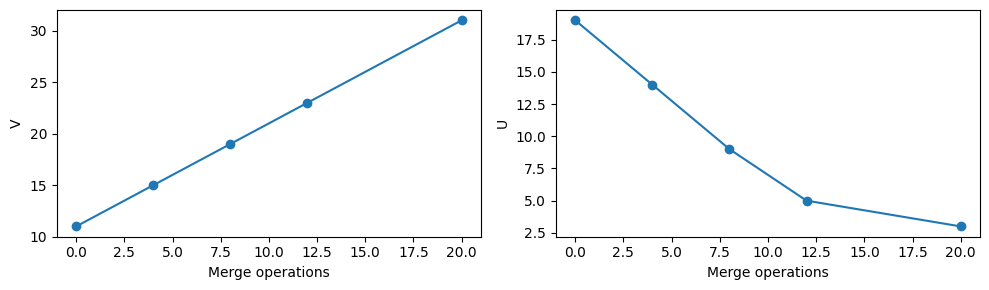

690

In [ ]:
rows = []
for budget in [0, 4, 8, 12, 20]:
    rules, vocabulary, _, _ = train_bpe(CORPUS, budget)
    ts, _ = encode_bpe(TEXT, rules, vocabulary)
    rows.append({'merges': len(rules), 'V': len(vocabulary),
                 'U': len(ts), 'tokens': ' | '.join(ts)})
display(pd.DataFrame(rows))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, key in zip(axes, ['V', 'U']):
    ax.plot([r['merges'] for r in rows], [r[key] for r in rows], '-o')
    ax.set(xlabel='Merge operations', ylabel=key)
plt.tight_layout(); plt.show()
Path('bpe_demo.json').write_text(json.dumps({'vocab': vocab, 'merges': merges},
                                           ensure_ascii=False, indent=2), encoding='utf-8')


## 확인 질문
1. `newer`의 빈도를 크게 올리면 앞쪽 병합 순서가 어떻게 변하나요?
2. 추론 과정에서 학습하지 않은 **단어**와 학습하지 않은 **문자**는 왜 다른 문제인가요?
3. 어휘 크기가 같으면 서로 다른 토크나이저의 ID를 바꿔 써도 될까요?